In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path
import mrich
from mrich import print
import re
import json

In [2]:
urls = [
    "https://www.cazoo.co.uk/cars/audi/a3/s-line/automatic/petrol/hatchback/2023/?postcode=GU22+7TQ&radius=100&doors=4+doors%2C5+doors&excludeImports=true&excludeCategoryNAndD=true&excludeCategorySAndC=true&isYear=true&maxAgeYear=1&sort=cheapest&carMileageMax=40000",
    
]

In [4]:
data = []

price_hashes = []

for file in sorted(list(Path("data/cazoo").glob("*.html"))):

    mrich.bold(file.name)

    bits = file.name.removesuffix(".html").split("_")

    year = int(bits[0])
    brand = bits[1]
    model = bits[2]
    engine = int(bits[3])
    trim = bits[4]
    doors = int(bits[5][0])

    # mrich.var("year", year)
    # mrich.var("model", model)
    # mrich.var("engine", engine)
    # mrich.var("trim", trim)

    text = open(file, "rt").read()
    
    # match = re.findall(r'<script type="application\/ld\+json">(.*?)<\/script>', text)
    # prices = re.findall(r'<span class="flex items-baseline gap-2"><span class="c-text-lg-semi-bold md:c-heading-xl">(.*?)<\/span>', text)
    prices = re.findall(r'<span>£(.*?)<\/span>', text)

    prices = sorted([int(p.replace(",", "")) for p in prices])

    print(prices)

    for price in prices:

        if price < 5000:
            continue

        data.append(dict(
            model=model,
            year=year,
            engine=engine,
            trim=trim,
            doors=doors,
            price=price,
        ))

df = pd.DataFrame(data) #.set_index("id")
# df["year"] = df["year"].astype(int)
# df

 2021_Audi_A3_35_BlackEd_5dr.html

[]

 2021_Audi_A3_35_SLine_5dr.html

[
    18999,
    18999,
    19000,
    19299,
    19299,
    19499,
    19499,
    19695,
    20150,
    20400,
    20450,
    20584,
    20609,
    20799,
    20799,
    21000,
    21449,
    21449,
    21495,
    21575,
    21799,
    21799,
    22197,
    22990
]

 2022_Audi_A3_35_BlackEd_5dr.html

...

[35652]

 2025_Audi_A3_35_SLine_5dr.html

[
    27190,
    27390,
    27598,
    27790,
    27985,
    28100,
    28295,
    28498,
    28750,
    28849,
    28864,
    28895,
    28961,
    28990,
    28990,
    28999,
    29100,
    29214,
    29277,
    29290,
    29350,
    29444,
    29465,
    29465
]

 2025_Audi_A3_35_Sport_5dr.html

[23600, 25384, 27998]

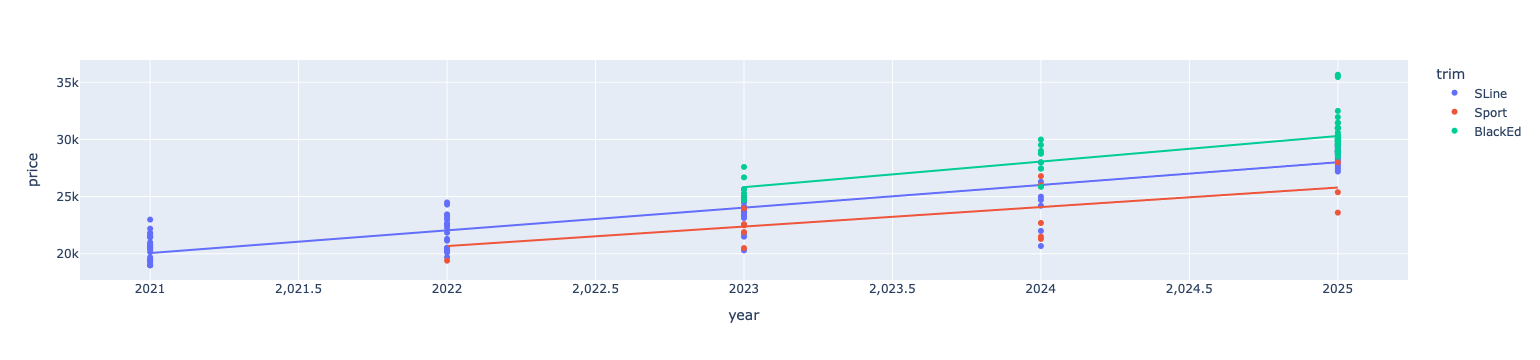

In [7]:
# px.scatter(df[df["trim"] == "Sline"], x="year", y="price")
px.scatter(df, x="year", y="price", color="trim", trendline="ols")